In [1]:
import os
import random
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import datetime
import pickle

import kagglehub

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 5

# Keep it simple: seed (optional, for repeatability of split)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-05-10 09:24:42.054179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778405082.232493      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778405082.283273      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778405082.691044      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778405082.691094      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778405082.691097      23 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path = kagglehub.dataset_download('faysalmiah1721758/potato-dataset')
print("Data download complete:", dataset_path)

DATASET_DIR = dataset_path

class_names = sorted(os.listdir(DATASET_DIR))
print("Class names:", class_names)

Data download complete: /kaggle/input/datasets/faysalmiah1721758/potato-dataset
Class names: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [3]:
file_paths = []
labels = []

for label_index, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)
    for fname in os.listdir(class_dir):
        file_paths.append(os.path.join(class_dir, fname))
        labels.append(label_index)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total images:", len(labels))

Total images: 2152


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    file_paths, labels, test_size=0.20, stratify=labels, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 1721, Val: 215, Test: 216


In [5]:
class_weight_vals = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=y_train
)
class_weight = dict(enumerate(class_weight_vals))
print("Class weights:", class_weight)

Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}


In [6]:
from tensorflow.keras.applications.efficientnet import preprocess_input

IMAGE_SIZE_EFF = (224, 224)

def load_dataset_effnet(file_paths, labels, augment=False, shuffle=True, seed=42):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    def process(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, IMAGE_SIZE_EFF)

        if augment:
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, max_delta=0.1)
            image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

        # EfficientNet preprocessing (expects float32)
        image = tf.cast(image, tf.float32)
        image = preprocess_input(image)

        label = tf.one_hot(label, depth=len(class_names))
        return image, label

    ds = ds.map(process, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=seed, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds_eff = load_dataset_effnet(X_train, y_train, augment=True, shuffle=True, seed=SEED)
val_ds_eff   = load_dataset_effnet(X_val, y_val, augment=False, shuffle=False, seed=SEED)
test_ds_eff  = load_dataset_effnet(X_test, y_test, augment=False, shuffle=False, seed=SEED)

print("EfficientNet datasets ready.")

I0000 00:00:1778405097.992661      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


EfficientNet datasets ready.


In [7]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet_b0(num_classes=3, input_shape=(224, 224, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    # Enable fine-tuning
    backbone.trainable = True

    # Freeze earlier layers
    for layer in backbone.layers[:-20]:
        layer.trainable = False

    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="EfficientNetB0_finetuned")

    return model

effnet_model = build_efficientnet_b0(
    num_classes=len(class_names)
)

effnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_finetuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 1,354,803 (5.17 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def train_and_evaluate_model_effnet(model, model_name, train_ds, val_ds, test_ds, class_names, class_weight, epochs=50):
    os.makedirs("models", exist_ok=True)
    os.makedirs("history", exist_ok=True)

    timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    run_name = f"{model_name}_{timestamp}"

    model_path = f"models/{run_name}.h5"
    history_path = f"history/{run_name}_history.pkl"
    plot_path = f"history/{run_name}_plot.png"
    cm_path = f"history/{run_name}_confusion_matrix.png"

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    checkpoint = ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stop, checkpoint],
        class_weight=class_weight
    )

    with open(history_path, "wb") as f:
        pickle.dump(history.history, f)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\n[{model_name}] Test Accuracy: {test_acc:.4f}")
    print(f"[{model_name}] Test Loss: {test_loss:.4f}")

    # Predictions
    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.tight_layout()
    plt.savefig(cm_path)
    plt.show()

    # Curves
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(plot_path)
    plt.show()

    print(f"\nSaved model: {model_path}")
    print(f"Saved history: {history_path}")
    print(f"Saved plot: {plot_path}")
    print(f"Saved confusion matrix: {cm_path}")

    return test_acc, test_loss

Epoch 1/50


I0000 00:00:1778405117.240878      64 service.cc:152] XLA service 0x7a916c114790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778405117.240920      64 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778405119.999388      64 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-10 09:25:25.592339: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 09:25:25.799402: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778405133.983300      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proc

53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7334 - loss: 0.7059

2026-05-10 09:25:42.481499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 09:25:42.690895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7354 - loss: 0.7019

...

54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 1.0000 - loss: 8.8182e-04 - val_accuracy: 1.0000 - val_loss: 5.4304e-04
Epoch 44/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 5.5222e-04
Epoch 45/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9994 - loss: 0.0019

54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9994 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 4.1070e-04
Epoch 46/50
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0014

54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 3.5306e-04
Epoch 47/50
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 6.5547e-04

54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 1.0000 - loss: 6.5653e-04 - val_accuracy: 1.0000 - val_loss: 2.9809e-04
Epoch 48/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 1.0000 - loss: 5.7783e-04 - val_accuracy: 1.0000 - val_loss: 3.1665e-04
Epoch 49/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 3.1733e-04

54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 1.0000 - loss: 3.2253e-04 - val_accuracy: 1.0000 - val_loss: 2.5645e-04
Epoch 50/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9994 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 5.1373e-04

[EfficientNetB0] Test Accuracy: 1.0000
[EfficientNetB0] Test Loss: 0.0014

Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight       1.00      1.00      1.00       100
 Potato___Late_blight       1.00      1.00      1.00       100
     Potato___healthy       1.00      1.00      1.00        16

             accuracy                           1.00       216
            macro avg       1.00      1.00      1.00       216
         weighted avg       1.00      1.00      1.00       216



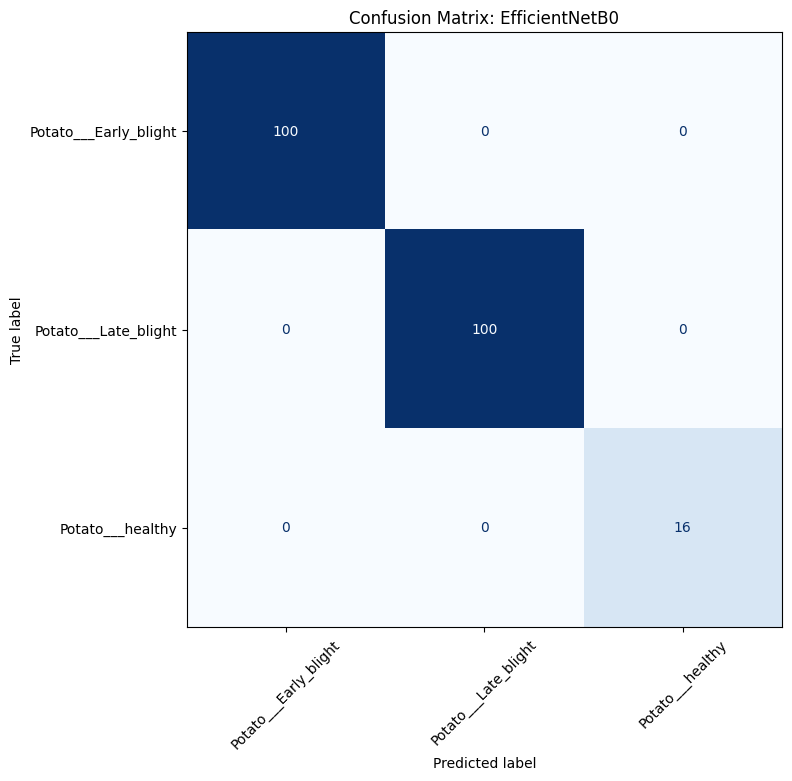

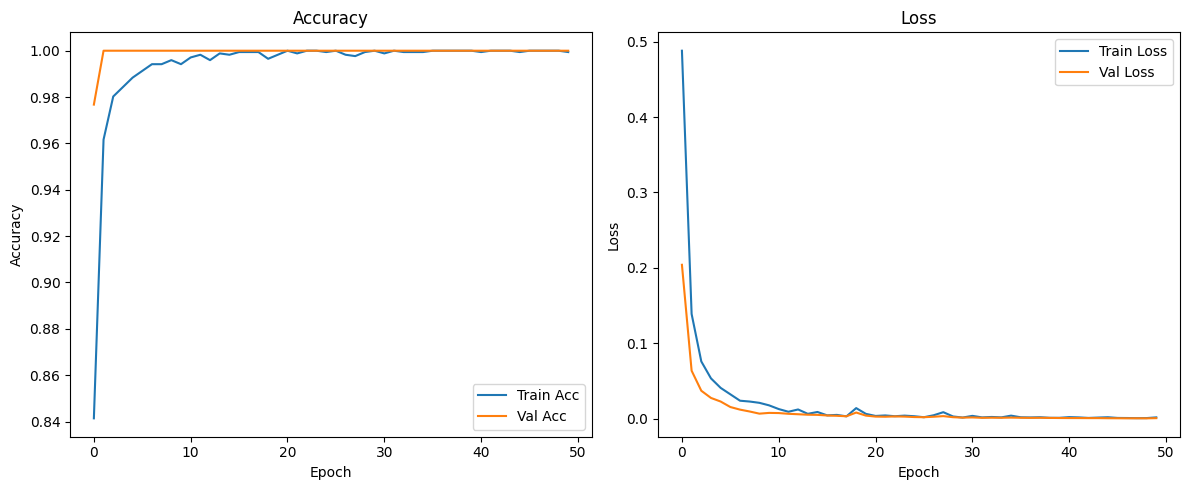


Saved model: models/EfficientNetB0_20260510-092503.h5
Saved history: history/EfficientNetB0_20260510-092503_history.pkl
Saved plot: history/EfficientNetB0_20260510-092503_plot.png
Saved confusion matrix: history/EfficientNetB0_20260510-092503_confusion_matrix.png

EfficientNetB0 Final: 1.0 0.0014395994367077947


In [9]:
effnet_model = build_efficientnet_b0(num_classes=len(class_names))
effnet_acc, effnet_loss = train_and_evaluate_model_effnet(
    model=effnet_model,
    model_name="EfficientNetB0",
    train_ds=train_ds_eff,
    val_ds=val_ds_eff,
    test_ds=test_ds_eff,
    class_names=class_names,
    class_weight=class_weight,
    epochs=EPOCHS
)

print("\nEfficientNetB0 Final:", effnet_acc, effnet_loss)

In [10]:
def count_params_millions(model):
    return model.count_params() / 1e6

print("EfficientNetB0 params (M):", round(count_params_millions(effnet_model), 2))

EfficientNetB0 params (M): 4.05
